In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
!pip install astra_toolbox
import astra
import matplotlib.pyplot as plt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.5/13.5 MB 11.4 MB/s eta 0:00:00


In [ ]:
# Random ellipses generator.
def random_ellipses(num_of_ellipses: int,
                    size: tuple) -> torch.Tensor:

    # Pre-allocate PyTorch tensor for the ellipses
    ellipses = torch.zeros(size=((num_of_ellipses, ) + (size[0], size[1])))

    # Create linear spaces for the ellipses to be put into.
    # Note that x is a row vector and y is a column vector.
    x = torch.linspace(start=-size[0], end=size[1], steps=size[1])
    y = torch.linspace(start=-size[0], end=size[1], steps=size[0])[:,None]

    # Loop over the amount of ellipses needed.
    for k in range(num_of_ellipses):
        # Find a random points for center coordinates, height and width.
        x0 = np.random.randint(low=-size[0], high=size[0])
        y0 = np.random.randint(low=-size[1], high=size[1])
        a = np.random.randint(low=-size[0], high=size[0])
        b = np.random.randint(low=-size[1], high=size[1])

        # Use ellipse function to create them.
        ellipses[k,:,:] = ((x-x0)/a)**2 + ((y-y0)/b)**2 <= 1

        # Force the ellipse value to be random constant from uniform distribution
        # for each ellipse.
        ellipses[k,:,:][ellipses[k,:,:] == 1] = torch.rand(1)

    # Sum all ellipses together and normalize the data to be in [0,1].
    ellipses = torch.sum(ellipses, dim=0)
    ellipses /= torch.max(ellipses)

    return ellipses

# Define class for double convolution with ReLU-activations
class DoubleConvAndReLU(nn.Module):
    '''
    Class for double convolutions (2D) and ReLUs that are used in the standard U-Net architecture.
    '''
    def __init__(self,
                 in_channels: int,
                 out_channels: int,
                 conv_kernel_size: tuple,
                 padding: int) -> None:
        super().__init__()

        self.in_channels = in_channels
        self.out_channels = out_channels
        self.conv_kernel_size = conv_kernel_size
        self.padding = padding

        self.double_conv_and_ReLU = nn.Sequential(
            nn.Conv2d(in_channels=self.in_channels,
                      out_channels=self.out_channels,
                      kernel_size=self.conv_kernel_size,
                      padding=self.padding),
            nn.ReLU(),
            nn.Conv2d(in_channels=self.out_channels,
                      out_channels=self.out_channels,
                      kernel_size=self.conv_kernel_size,
                      padding=self.padding),
            nn.ReLU()
        )

    def forward(self,
                input_tensor: torch.Tensor) -> torch.Tensor:
        return self.double_conv_and_ReLU(input_tensor)

class encoding(nn.Module):
    '''
    Class for the encoding part of the U-Net.
    This network should go up to 256 channels.
    '''
    def __init__(self,
                 in_channels: int,
                 kernel_size: tuple,
                 max_pool_kernel_size: tuple,
                 padding: int) -> torch.Tensor:
        super().__init__()

        ### Defining instance variables
        self.in_channels = in_channels
        self.kernel_size = kernel_size
        self.max_pool_kernel_size = max_pool_kernel_size
        self.padding = padding

        self.convs_and_relus1 = DoubleConvAndReLU(self.in_channels, out_channels=32, conv_kernel_size=self.kernel_size, padding=self.padding)
        self.maxpool1 = nn.MaxPool2d(kernel_size=self.max_pool_kernel_size)
        self.convs_and_relus2 = DoubleConvAndReLU(in_channels=32, out_channels=64, conv_kernel_size=self.kernel_size, padding=self.padding)
        self.maxpool2 = nn.MaxPool2d(kernel_size=self.max_pool_kernel_size)
        self.convs_and_relus3 = DoubleConvAndReLU(in_channels=64, out_channels=128, conv_kernel_size=self.kernel_size, padding=self.padding)
        self.maxpool3 = nn.MaxPool2d(kernel_size=self.max_pool_kernel_size)
        self.convs_and_relus4 = DoubleConvAndReLU(in_channels=128, out_channels=256, conv_kernel_size=self.kernel_size, padding=self.padding)

    ### Must have forward function. Follows skip connecting UNet architechture
    def forward(self, g):
        g_start = g
        encoding_features = []
        g = self.convs_and_relus1(g)
        encoding_features.append(g)
        g = self.maxpool1(g)
        g = self.convs_and_relus2(g)
        encoding_features.append(g)
        g = self.maxpool2(g)
        g = self.convs_and_relus3(g)
        encoding_features.append(g)
        g = self.maxpool3(g)
        g = self.convs_and_relus4(g)

        return g, encoding_features, g_start

### Class for decoding part of the UNet. This is the part of the UNet which
### goes back up with transpose of the convolution
class decoding(nn.Module):
    '''
    Class for decoding part of the UNet. This is the part of the UNet which
    goes back up with transpose of the convolution.
    '''
    def __init__(self,
                 out_channels: int,
                 kernel_size: tuple,
                 transpose_kernel_size: tuple,
                 transpose_padding: int,
                 stride: int,
                 padding: int) -> torch.Tensor:
        super().__init__()

        ### Defining instance variables
        self.out_channels = out_channels
        self.kernel_size = kernel_size
        self.transpose_kernel_size = transpose_kernel_size
        self.transpose_padding = transpose_padding
        self.stride = stride
        self.padding = padding

        self.transpose1 = nn.ConvTranspose2d(in_channels=256, out_channels=128,
                                             kernel_size=self.transpose_kernel_size, stride=self.stride,
                                             padding=self.transpose_padding)
        self.convs_and_relus1 = DoubleConvAndReLU(in_channels=256, out_channels=128,
                                                  conv_kernel_size=self.kernel_size, padding=self.padding)
        self.transpose2 = nn.ConvTranspose2d(in_channels=128, out_channels=64,
                                             kernel_size=self.transpose_kernel_size, stride=self.stride,
                                             padding=self.transpose_padding)
        self.convs_and_relus2 = DoubleConvAndReLU(in_channels=128, out_channels=64,
                                                  conv_kernel_size=self.kernel_size, padding=self.padding)
        self.transpose3 = nn.ConvTranspose2d(in_channels=64, out_channels=32,
                                             kernel_size=self.transpose_kernel_size, stride=self.stride,
                                             padding=self.transpose_padding)
        self.convs_and_relus3 = DoubleConvAndReLU(in_channels=64, out_channels=32,
                                                  conv_kernel_size=self.kernel_size, padding=self.padding)
        self.final_conv = nn.Conv2d(in_channels=32, out_channels=self.out_channels,
                                    kernel_size=self.kernel_size, padding=1)

    ### Must have forward function. Follows skip connecting UNet architechture
    def forward(self, g, encoding_features, g_start):
        g = self.transpose1(g)
        g = torch.cat([g, encoding_features[-1]], dim=1)
        encoding_features.pop()
        g = self.convs_and_relus1(g)
        g = self.transpose2(g)
        g = torch.cat([g, encoding_features[-1]], dim=1)
        encoding_features.pop()
        g = self.convs_and_relus2(g)
        g = self.transpose3(g)
        g = torch.cat([g, encoding_features[-1]], dim=1)
        encoding_features.pop()
        g = self.convs_and_relus3(g)
        g = self.final_conv(g)

        g = g_start + g

        return g

class UNet(nn.Module):
    '''
    Class for the U-Net architecture.
    This class calls the encoder and decoder classes
    '''
    def __init__(self,
                 in_channels: int,
                 out_channels: int,
                 kernel_size: tuple,
                 max_pool_kernel_size: tuple,
                 transpose_kernel_size: tuple,
                 transpose_padding: int,
                 stride: int,
                 padding: int) -> torch.Tensor:
        super().__init__()

        ### Defining instance variables
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.kernel_size = kernel_size
        self.max_pool_kernel_size = max_pool_kernel_size
        self.transpose_kernel_size = transpose_kernel_size
        self.transpose_padding = transpose_padding
        self.stride = stride
        self.padding = padding

        self.encoder = encoding(in_channels=self.in_channels,
                                kernel_size=self.kernel_size,
                                max_pool_kernel_size=self.max_pool_kernel_size,
                                padding=self.padding)
        self.decoder = decoding(out_channels=self.out_channels,
                                kernel_size=self.kernel_size,
                                transpose_kernel_size=self.transpose_kernel_size,
                                transpose_padding=self.transpose_padding,
                                stride=self.stride,
                                padding=self.padding)

    ### Must have forward function. Calling encoder and deoder classes here
    ### and making the whole UNet model
    def forward(self, g):
        g, encoding_features, g_start = self.encoder(g)
        g = self.decoder(g, encoding_features, g_start)

        return g

tensor(1.)


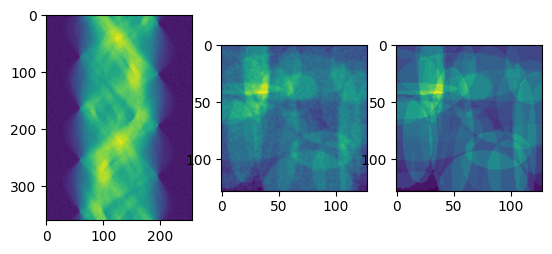

In [ ]:
# Assign device.
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# Generate testing data. Keep them as torch-tensor.
amount_of_test = 5
amount_of_ellipses = 50
image_size = (128,128)
test_images = torch.zeros(size=(amount_of_test, ) + (image_size))
for k in range(amount_of_test):
    test_images[k,:,:] = random_ellipses(num_of_ellipses=amount_of_ellipses, size=image_size)
print(torch.max(test_images))

# test_images = torch.load('test_images.pt')
# image_size = (test_images.shape[1], test_images.shape[2])
# amount_of_test = test_images.shape[0]

# Create a volume geometry of a size of variable "size".
vol_geom = astra.create_vol_geom(image_size)

# Define variables for the Fan-Beam projection.
num_of_lines = 256
start_angle = 0
end_angle = 2*np.pi
amount_of_angles = 360
angles = np.linspace(start_angle, end_angle, amount_of_angles)
SOD = 250
SDD = 260

# Create the Fan-Beam projction.
proj_geom = astra.create_proj_geom('fanflat', 1.0, num_of_lines, angles, SOD, SDD-SOD)

# Create a sinogram using the CPU or GPU.
proj_id = astra.create_projector('cuda',proj_geom, vol_geom)
# sinogram = astra.create_sino(ellipses, proj_id)[1]


# Add x% of mean zero noise on every test image.
percentage = 0.02
mean = 0

test_noisy_sinograms = torch.zeros(size=(amount_of_test, ) + (amount_of_angles, num_of_lines))
test_noisy_sinogram_ids = []
test_recos = torch.zeros(size=(amount_of_test, ) + (image_size))
for k in range(amount_of_test):
    proj_id = astra.create_projector('cuda',proj_geom, vol_geom)

    test_sinogram = astra.create_sino(test_images[k,:,:].numpy(), proj_id)[1]

    test_sinogram = torch.as_tensor(astra.create_sino(test_images[k,:,:].numpy(), proj_id)[1])
    noise = torch.normal(mean=mean, std=torch.max(test_sinogram), size=test_sinogram.shape) * percentage
    test_noisy_sinogram_ids.append(astra.data2d.create('-sino', proj_geom, (test_sinogram + noise).numpy()))
    test_noisy_sinograms[k,:,:] = test_sinogram + noise
    # Define reconstruction id.
    rec_id = astra.data2d.create('-vol', vol_geom)

    # Create Filtered Back-Projection operator.
    FBP = astra.astra_dict('FBP_CUDA')

    # Create FBP reconstruction.
    cfg = FBP
    cfg['ReconstructionDataId'] = rec_id
    cfg['ProjectionDataId'] = test_noisy_sinogram_ids[k]
    cfg['option'] = { 'FilterType': 'Hann' }

    alg_id = astra.algorithm.create(cfg)
    astra.algorithm.run(alg_id)

    # test_recos[k,:,:] = torch.as_tensor(np.maximum(0, astra.data2d.get(rec_id)))
    test_recos[k,:,:] = torch.as_tensor(astra.data2d.get(rec_id))
    # test_recos[k,:,:] = np.maximum(0, test_recos[k,:,:])

    # Free memory, THIS IS EXTREMELY NECESSARY WITH ASTRA!
    astra.data2d.delete(test_noisy_sinogram_ids[k])
    astra.projector.delete(proj_id)
    astra.algorithm.delete(alg_id)
    astra.data2d.delete(rec_id)

_, ax = plt.subplots(1,3)
ax[0].imshow(test_noisy_sinograms[0,:,:].numpy())
ax[1].imshow(test_recos[0,:,:].numpy())
ax[2].imshow(test_images[0,:,:].numpy())
plt.show()

In [ ]:
# Define loss functions.
train_loss = nn.MSELoss()
test_loss = nn.MSELoss()

# Initialize the network.
unet = UNet(in_channels=1,
            out_channels=1,
            kernel_size=(3,3),
            max_pool_kernel_size=(2,2),
            transpose_kernel_size=(2,2),
            transpose_padding=0,
            stride=2,
            padding=1).to(device)

unet_parameters = list(unet.parameters())

def psnr(max_val, loss):

    psnr = 10 * np.log10((max_val**2)/(loss+1e-10))

    return psnr

In [ ]:
def network_training(network, iterations, learning_rate):
    optimizer = optim.Adam(unet_parameters, lr=learning_rate)

    for k in range(iterations):
        train_image = random_ellipses(num_of_ellipses=amount_of_ellipses, size=image_size)

        proj_id = astra.create_projector('cuda',proj_geom, vol_geom)

        train_sinogram = astra.create_sino(train_image.numpy(), proj_id)[1]

        train_sinogram = torch.as_tensor(astra.create_sino(train_image.numpy(), proj_id)[1])
        noise = torch.normal(mean=mean, std=torch.max(train_sinogram), size=train_sinogram.shape) * percentage
        train_noisy_sinogram_id = astra.data2d.create('-sino', proj_geom, (train_sinogram + noise).numpy())
        train_noisy_sinogram = train_sinogram + noise
        # Define reconstruction id.
        rec_id = astra.data2d.create('-vol', vol_geom)

        # Create Filtered Back-Projection operator.
        FBP = astra.astra_dict('FBP_CUDA')

        # Create FBP reconstruction.
        cfg = FBP
        cfg['ReconstructionDataId'] = rec_id
        cfg['ProjectionDataId'] = train_noisy_sinogram_id
        cfg['option'] = { 'FilterType': 'Hann' }

        alg_id = astra.algorithm.create(cfg)
        astra.algorithm.run(alg_id)

        # test_recos[k,:,:] = torch.as_tensor(np.maximum(0, astra.data2d.get(rec_id)))
        train_reco = torch.as_tensor(astra.data2d.get(rec_id))
        # test_recos[k,:,:] = np.maximum(0, test_recos[k,:,:])

        # Free memory, THIS IS EXTREMELY NECESSARY WITH ASTRA!
        astra.data2d.delete(train_noisy_sinogram_id)
        astra.projector.delete(proj_id)
        astra.algorithm.delete(alg_id)
        astra.data2d.delete(rec_id)

        train_image = train_image[None,None,:,:].to(device)
        train_reco = train_reco[None,None,:,:].to(device)

        network.train()

        outputs = network(train_reco)

        optimizer.zero_grad()

        loss = train_loss(outputs, train_image)

        loss.backward()

        optimizer.step()

        if k % 1000 == 0:

            test_outputs = network(test_recos[:,None,:,:].to(device))

            testing_loss = test_loss(test_outputs, test_images[:,None,:,:].to(device)).item()

            # writer.add_scalar('Test Loss', testing_loss, k)
            # writer.add_scalar('PSNR', psnr(torch.max(test_images).item(), testing_loss), k)
            # writer.add_image('Testing ouput', test_outputs[0,0,:,:], k, dataformats='HW')
            # writer.add_image('Testing Ground truth', test_images[0,:,:], k, dataformats='HW')
            # writer.flush()

            plt.figure()
            plt.subplot(1,2,1)
            plt.imshow(test_outputs[4,0,:,:].cpu().detach().numpy())
            plt.subplot(1,2,2)
            plt.imshow(test_images[4,:,:].cpu().detach().numpy())
            plt.show()

            print(f'PSNR after iter {k}: ', psnr(torch.max(test_images).item(), testing_loss))

    return network

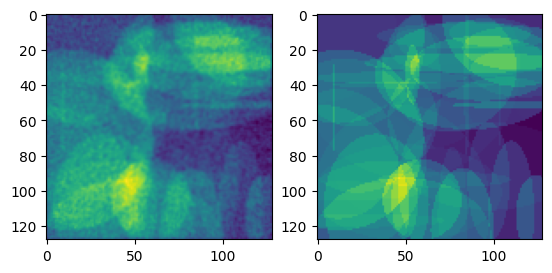

PSNR after iter 0:  27.377424418351787


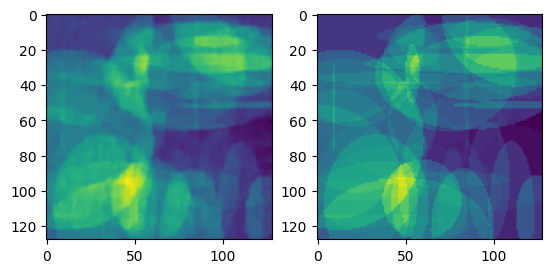

PSNR after iter 1000:  31.592225426592893


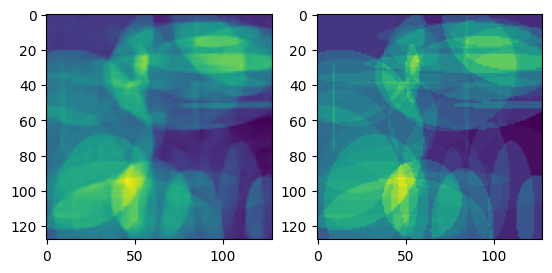

PSNR after iter 2000:  32.001630917403794


In [ ]:
trained_network = network_training(unet, 50001, 0.001)